# Supply Chain Performance & Operations Analytics Dashboard
This project analyses **180,519 orders** from the DataCo Global Supply Chain dataset
to uncover delivery inefficiencies, supplier risk patterns, and profitability gaps
across 23 regions and 4 shipping modes.

Using **Python** for data preparation and anomaly detection, and **Power BI** for
interactive visualisation, the goal is to turn raw transaction data into a dashboard
that answers one core business question:

> *"Where is our supply chain failing — and what is it costing us?"*

---

## 📦 Phase 1 — Data Ingestion & Exploration
This is the **first notebook** in a five-phase analytics pipeline built using Python and Power BI.
Before we clean, engineer, or model anything — we need to deeply understand the raw data.

### 🎯 Objectives
| # | Task |
|---|---|
| 1 | Load the raw DataCo Supply Chain CSV |
| 2 | Inspect shape, columns, and data types |
| 3 | Analyse descriptive statistics |
| 4 | Identify missing values and duplicates |
| 5 | Explore key business columns |
| 6 | Visualise distributions and correlations |
| 7 | Document all findings for Phase 2 |

### 🚫 What this notebook does NOT do
We do **not** fix, transform, or engineer anything here.
This notebook is read-only — we observe and document. All fixes happen in Phase 2.

---

> **Project:** Supply Chain Performance & Operations Analytics Dashboard  
> **Dataset:** DataCoSupplyChainDataset.csv (180,519 rows × 53 columns)  
> **Tools:** Python 3 | Pandas | NumPy | Matplotlib | Seaborn | Jupyter Notebook  
> **Next:** `02_data_cleaning_feature_engineering.ipynb`

# Import Libraries

In [1]:
# Import core data libraries 
import pandas as pd          # Main library for working with tabular data (DataFrames)
import numpy as np           # Numerical operations and array handling

# Import visualisation libraries 
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Higher-level statistical visualisation

# Suppress non-critical warnings 
import warnings
warnings.filterwarnings('ignore')  # Hides harmless deprecation/version warnings

# Set display options 
pd.set_option('display.max_columns', None)              # Show ALL columns, never truncate
pd.set_option('display.max_rows', 100)                  # Show up to 100 rows at once
pd.set_option('display.float_format', '{:.2f}'.format) # Round all floats to 2 decimal places

# Set a consistent plot style 
sns.set_style('whitegrid')               # Clean white background with subtle grid lines
plt.rcParams['figure.figsize'] = (12, 5) # Default chart size: 12 inches wide x 5 tall

print("All libraries imported successfully.")

All libraries imported successfully.


# Load Files

In [2]:
# Define base project path 
# r'...' = raw string — backslashes are treated as literal characters, not escape sequences
BASE_PATH = r'C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard'

# Path to the main dataset  
MAIN_DATA   = BASE_PATH + r'\DataCoSupplyChainDataset.csv'

# Path to the data dictionary (our reference guide for column meanings) 
DICT_DATA   = BASE_PATH + r'\DescriptionDataCoSupplyChain.csv'

# Output folder — to export clean CSVs here in Phase 2 
OUTPUT_PATH = BASE_PATH + r'\data\processed'   

# Confirm paths are set correctly 
print(f" Base path   : {BASE_PATH}")
print(f" Main data   : {MAIN_DATA}")
print(f" Dictionary  : {DICT_DATA}")
print(f" Output path : {OUTPUT_PATH}")

 Base path   : C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard
 Main data   : C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard\DataCoSupplyChainDataset.csv
 Dictionary  : C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard\DescriptionDataCoSupplyChain.csv
 Output path : C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard\data\processed


In [3]:
# Load the main dataset into a Pandas DataFrame 
# encoding='latin-1' handles special characters in city/country name columns
df = pd.read_csv(MAIN_DATA, encoding='latin-1')

# Confirm the load was successful 
print(f" Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]:,}")   # .shape[0] = total number of rows
print(f"   Columns : {df.shape[1]}")     # .shape[1] = total number of columns
print(f"   Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
# memory_usage(deep=True) measures actual RAM used by the DataFrame
# / 1024**2 converts bytes → megabytes

 Dataset loaded successfully!
   Rows    : 180,519
   Columns : 53
   Memory  : 332.6 MB


In [4]:
# Load the data dictionary 
# We wrap this in try/except so the notebook doesn't crash if the file is missing
try:
    dict_df = pd.read_csv(DICT_DATA, encoding='latin-1')

    print(f"✅ Data dictionary loaded: {dict_df.shape[0]} column descriptions found.")
    print()

    # Show all rows — we want to read every single column description
    pd.set_option('display.max_rows', None)   # Temporarily remove the 100-row limit
    display(dict_df)                          # display() renders a formatted table in Jupyter
    pd.set_option('display.max_rows', 100)    # Reset back to 100 after displaying

except FileNotFoundError:
    # If the file isn't found, warn but keep running — it's a reference file, not critical
    print(" Description file not found. Proceed with manual column inspection below.")

✅ Data dictionary loaded: 52 column descriptions found.



,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer
5,Delivery Status,: Delivery status of orders: Advance shipping...
6,Late_delivery_risk,: Categorical variable that indicates if send...
7,Category Id,: Product category code
8,Category Name,: Description of the product category
9,Customer City,: City where the customer made the purchase


# EDA

In [5]:
# Preview the first 5 rows 
print("First 5 rows:")
df.head()

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.00,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
# Preview the last 5 rows 
print("Last 5 rows:")
df.tail()

Last 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.00,399.98,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.00,7,Fan Shop,40.64,-73.94,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.00,0.00,65177,399.98,0.10,1,399.98,399.98,40.00,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.77,395.98,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.00,7,Fan Shop,35.36,-119.02,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.00,0.01,65161,399.98,-1.55,1,399.98,395.98,-613.77,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.11,391.98,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.00,7,Fan Shop,41.63,-72.97,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.00,0.02,65129,399.98,0.36,1,399.98,391.98,141.11,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.23,387.98,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.00,7,Fan Shop,18.21,-66.37,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.00,0.03,65126,399.98,0.48,1,399.98,387.98,186.23,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.95,383.98,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.00,7,Fan Shop,18.29,-66.37,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.00,0.04,65113,399.98,0.44,1,399.98,383.98,168.95,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/19/2016 18:54,Standard Class


In [7]:
# Preview 5 random rows 
# .sample() picks random rows — helps spot edge cases that head/tail always skip
# random_state=42 makes the random selection reproducible (same rows every run)
print("Random sample of 5 rows:")
df.sample(5, random_state=42)

Random sample of 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
80120,TRANSFER,5,4,11.09,175.99,Late delivery,1,48,Water Sports,Caguas,Puerto Rico,XXXXXXXXX,Zachary,6109,Tate,XXXXXXXXX,Consumer,PR,8916 Round Zephyr Ridge,725.00,7,Fan Shop,18.20,-66.37,USCA,Los Angeles,Estados Unidos,6109,4/1/2016 21:05,31299,1073,24.00,0.12,78239,199.99,0.06,1,199.99,175.99,11.09,West of USA,California,PROCESSING,90036.00,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.99,0,4/6/2016 21:05,Standard Class
19670,PAYMENT,2,1,9.80,245.00,Late delivery,1,24,Women's Apparel,Florissant,EE. UU.,XXXXXXXXX,Gary,12041,Oneal,XXXXXXXXX,Consumer,MO,372 Sunny Arbor,63033.00,5,Golf,38.81,-90.30,LATAM,Tegucigalpa,Honduras,12041,6/9/2017 18:43,61023,502,5.00,0.02,152658,50.00,0.04,5,250.00,245.00,9.80,Central America,Francisco Morazán,PENDING_PAYMENT,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.00,0,6/11/2017 18:43,First Class
114887,TRANSFER,2,4,117.55,244.90,Advance shipping,0,46,Indoor/Outdoor Games,Carmichael,EE. UU.,XXXXXXXXX,Andrea,4271,Alexander,XXXXXXXXX,Corporate,CA,2407 Foggy Acres,95608.00,7,Fan Shop,38.61,-121.32,LATAM,Tijuana,México,4271,1/2/2015 14:32,111,1014,5.00,0.02,253,49.98,0.48,5,249.90,244.90,117.55,Central America,Baja California,PROCESSING,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.98,0,1/4/2015 14:32,Standard Class
120110,TRANSFER,5,4,118.43,251.98,Late delivery,1,43,Camping & Hiking,Troy,EE. UU.,XXXXXXXXX,Joyce,3521,Callahan,XXXXXXXXX,Consumer,NY,4075 Silver Hills Heights,12180.00,7,Fan Shop,42.73,-73.69,Africa,Pretoria,SudAfrica,3521,1/10/2017 1:46,50699,957,48.00,0.16,126700,299.98,0.47,1,299.98,251.98,118.43,Southern Africa,Gauteng,PENDING,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.98,0,1/15/2017 1:46,Standard Class
56658,DEBIT,2,4,-21.59,107.97,Advance shipping,0,29,Shop By Sport,Caguas,Puerto Rico,XXXXXXXXX,Mildred,12073,Merritt,XXXXXXXXX,Consumer,PR,4661 Green Freeway,725.00,5,Golf,18.23,-66.37,LATAM,Santiago de los Caballeros,República Dominicana,12073,4/6/2017 7:15,56606,627,12.00,0.10,141586,39.99,-0.20,3,119.97,107.97,-21.59,Caribbean,Santiago de Chile,COMPLETE,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.99,0,4/8/2017 7:15,Standard Class


In [8]:
# Full structural summary of the entire DataFrame 
# .info() shows: index | column name | non-null count | dtype
# verbose=True shows every column
# show_counts=True shows the non-null count per column
print("Full dataset structural summary:\n")
df.info(verbose=True, show_counts=True)

Full dataset structural summary:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 

In [9]:
# Descriptive statistics for all numeric columns 
# .describe() computes count, mean, std, min, quartiles, max for every numeric column
# .T transposes the result — rotates rows and columns — so each column becomes a row
# This makes it much easier to read when there are many columns
print("Numeric column statistics:\n")
df.describe().T.style.background_gradient(cmap='Blues')
# background_gradient adds a color scale so high values are darker — easier to scan

Numeric column statistics:



,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.000000,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.000000,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.000000,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.000000,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.000000,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.000000,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.000000,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.000000,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.000000,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.000000,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [10]:
# Descriptive statistics for text columns 
# include='object' tells describe() to analyse text columns instead of numeric ones
# For text, describe() shows: count, unique value count, most frequent value, its frequency
print("Text column statistics:\n")
df.describe(include='object').T

Text column statistics:



,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Email,180519,1,XXXXXXXXX,180519
Customer Fname,180519,782,Mary,65150
Customer Lname,180511,1109,Smith,64104
Customer Password,180519,1,XXXXXXXXX,180519
Customer Segment,180519,3,Consumer,93504


In [11]:
# Count missing values per column 
# .isnull() → True/False for every cell | .sum() → count of True per column
missing_count = df.isnull().sum()

# Calculate what % of each column is missing
# Dividing by len(df) gives a proportion; × 100 converts to percentage
missing_pct = (df.isnull().sum() / len(df)) * 100

# Combine count and % into a single readable summary table
missing_summary = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct.round(2)
})

# Keep only columns that actually have missing values (count > 0)
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Sort worst columns first
missing_summary = missing_summary.sort_values('Missing %', ascending=False)

if len(missing_summary) == 0:
    print("No missing values found in the dataset!")
else:
    print(f" {len(missing_summary)} columns have missing values:\n")
    display(missing_summary)

 4 columns have missing values:



,Missing Count,Missing %
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


In [12]:
# Check for fully duplicate rows 
# .duplicated() returns True for every row that is an exact copy of a previous row
# .sum() counts the total number of duplicate rows found
dupe_count = df.duplicated().sum()

print(f"Duplicate rows found: {dupe_count:,}")

if dupe_count > 0:
    # Show what % of total rows are duplicates
    print(f"   That is {(dupe_count / len(df)) * 100:.2f}% of total rows.")
    print("\n   Preview of duplicated rows:")
    # keep=False marks ALL copies as True (not just the second occurrence)
    # This lets us see both the original and the duplicate side by side
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No duplicate rows found — nothing to remove.")

Duplicate rows found: 0
No duplicate rows found — nothing to remove.


# Explore Key Columns

In [13]:
# Explore: Delivery Status 
# .value_counts() counts how many rows have each unique value
# normalize=True converts counts to proportions; × 100 = percentage
print("Delivery Status — how orders are distributed:\n")

delivery_counts = df['Delivery Status'].value_counts()
delivery_pct    = df['Delivery Status'].value_counts(normalize=True) * 100

# Build a combined table showing both count and percentage
delivery_summary = pd.DataFrame({
    'Count'  : delivery_counts,
    'Percent': delivery_pct.round(2)
})
display(delivery_summary)

Delivery Status — how orders are distributed:



,Count,Percent
Delivery Status,,
Late delivery,98977,54.83
Advance shipping,41592,23.04
Shipping on time,32196,17.84
Shipping canceled,7754,4.30


In [14]:
# Explore: Late Delivery Risk 
# This is a binary column: 1 = order is at risk of being late, 0 = not at risk
# Taking the mean of a 0/1 column gives the proportion of 1s — the late risk rate
print("Late Delivery Risk:\n")

risk_counts = df['Late_delivery_risk'].value_counts().sort_index()
risk_pct    = df['Late_delivery_risk'].value_counts(normalize=True).sort_index() * 100

risk_summary = pd.DataFrame({
    'Meaning' : {0: 'Not at risk', 1: 'At risk of late delivery'},
    'Count'   : risk_counts,
    'Percent' : risk_pct.round(2)
})
display(risk_summary)

print(f"\n Overall late delivery risk rate: {df['Late_delivery_risk'].mean()*100:.1f}%")

Late Delivery Risk:



,Meaning,Count,Percent
0,Not at risk,81542,45.17
1,At risk of late delivery,98977,54.83



 Overall late delivery risk rate: 54.8%


In [15]:
# Explore: Shipping Mode 
print(" Shipping Mode — how orders are shipped:\n")
display(df['Shipping Mode'].value_counts().to_frame('Count'))

print("\n Order Region — where orders are placed:\n")
display(df['Order Region'].value_counts().to_frame('Count'))

print("\n Order Country — unique countries:\n")
print(f"   {df['Order Country'].nunique()} unique countries")
# .nunique() counts the number of unique values in a column
display(df['Order Country'].value_counts().head(15).to_frame('Count'))

 Shipping Mode — how orders are shipped:



,Count
Shipping Mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737



 Order Region — where orders are placed:



,Count
Order Region,
Central America,28341
Western Europe,27109
South America,14935
Oceania,10148
Northern Europe,9792
Southeast Asia,9539
Southern Europe,9431
Caribbean,8318
West of USA,7993



 Order Country — unique countries:

   164 unique countries


,Count
Order Country,
Estados Unidos,24840
Francia,13222
México,13172
Alemania,9564
Australia,8497
Brasil,7987
Reino Unido,7302
China,5758
Italia,4989


In [16]:
# Explore: Shipping days — the foundation of our delay calculation 
# real = how many days it actually took
# scheduled = how many days it was supposed to take
# delay = real minus scheduled (positive = late, negative = early)
print(" Shipping Days — Real vs Scheduled:\n")

for col in ['Days for shipping (real)', 'Days for shipment (scheduled)']:
    print(f"  {col}:")
    print(f"    Min    : {df[col].min()} days")
    print(f"    Max    : {df[col].max()} days")
    print(f"    Mean   : {df[col].mean():.2f} days")
    print(f"    Median : {df[col].median()} days")
    print()

# Preview: what would delay look like?
# We are NOT creating a new column yet — just previewing the calculation
preview_delay = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
print(f"  Preview — delay days (real minus scheduled):")
print(f"    Mean delay : {preview_delay.mean():.2f} days")
print(f"    Max delay  : {preview_delay.max()} days")
print(f"    Min delay  : {preview_delay.min()} days (negative = delivered early)")

 Shipping Days — Real vs Scheduled:

  Days for shipping (real):
    Min    : 0 days
    Max    : 6 days
    Mean   : 3.50 days
    Median : 3.0 days

  Days for shipment (scheduled):
    Min    : 0 days
    Max    : 4 days
    Mean   : 2.93 days
    Median : 4.0 days

  Preview — delay days (real minus scheduled):
    Mean delay : 0.57 days
    Max delay  : 4 days
    Min delay  : -2 days (negative = delivered early)


In [17]:
# Explore: Sales and Profit 
print(" Financial columns — Sales and Profit:\n")

# List the financial columns we expect — some Kaggle versions have slightly different names
financial_cols = [
    'Sales',
    'Order Profit Per Order',
    'Order Item Discount Rate',
    'Order Item Quantity',
    'Order Item Product Price'
]

# Filter to only columns that actually exist in this version of the dataset
existing = [c for c in financial_cols if c in df.columns]

display(df[existing].describe().T)

# Quick profit margin preview
if 'Sales' in df.columns and 'Order Profit Per Order' in df.columns:
    preview_margin = (df['Order Profit Per Order'] / df['Sales']) * 100
    print(f"\n  Profit margin preview:")
    print(f"    Mean margin : {preview_margin.mean():.2f}%")
    print(f"    Min margin  : {preview_margin.min():.2f}%")
    print(f"    Max margin  : {preview_margin.max():.2f}%")

 Financial columns — Sales and Profit:



,count,mean,std,min,25%,50%,75%,max
Sales,180519.00,203.77,132.27,9.99,119.98,199.92,299.95,1999.99
Order Profit Per Order,180519.00,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Order Item Discount Rate,180519.00,0.10,0.07,0.00,0.04,0.10,0.16,0.25
Order Item Quantity,180519.00,2.13,1.45,1.00,1.00,1.00,3.00,5.00
Order Item Product Price,180519.00,141.23,139.73,9.99,50.00,59.99,199.99,1999.99



  Profit margin preview:
    Mean margin : 10.83%
    Min margin  : -275.00%
    Max margin  : 50.04%


In [18]:
# Order-item structure analysis 
# Definition: since this dataset is at order-item level, understanding
# how many items per order exist is critical for correct aggregation later

print("Order-item structure analysis:\n")

items_per_order = df.groupby('Order Id').size()

print(f"   Unique orders        : {df['Order Id'].nunique():,}")
print(f"   Total order items    : {len(df):,}")
print(f"   Min items per order  : {items_per_order.min()}")
print(f"   Max items per order  : {items_per_order.max()}")
print(f"   Mean items per order : {items_per_order.mean():.2f}")
print(f"   Median items per order: {items_per_order.median():.0f}")

print(f"\n   Distribution of items per order:")
print(items_per_order.value_counts().sort_index().to_frame('Order count'))

Order-item structure analysis:

   Unique orders        : 65,752
   Total order items    : 180,519
   Min items per order  : 1
   Max items per order  : 5
   Mean items per order : 2.75
   Median items per order: 3

   Distribution of items per order:
   Order count
1        19850
2        11447
3        11398
4        11704
5        11353


# Visualizations

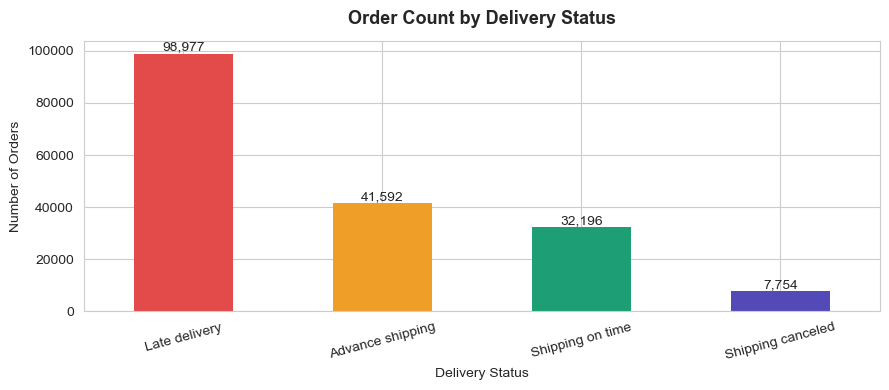

In [19]:
# Chart 1: Delivery Status distribution 
fig, ax = plt.subplots(figsize=(9, 4))

delivery_counts.plot(
    kind='bar',
    color=['#E24B4A', '#EF9F27', '#1D9E75', '#534AB7'],  # One color per category
    edgecolor='none',
    ax=ax
)

ax.set_title('Order Count by Delivery Status', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Delivery Status')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=15)  # Rotate labels slightly so they don't overlap

# Add exact count on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',               # Format number with comma separator
        (p.get_x() + p.get_width() / 2, p.get_height()),  # Position above bar centre
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.savefig('01_delivery_status.png', bbox_inches='tight')
plt.show()

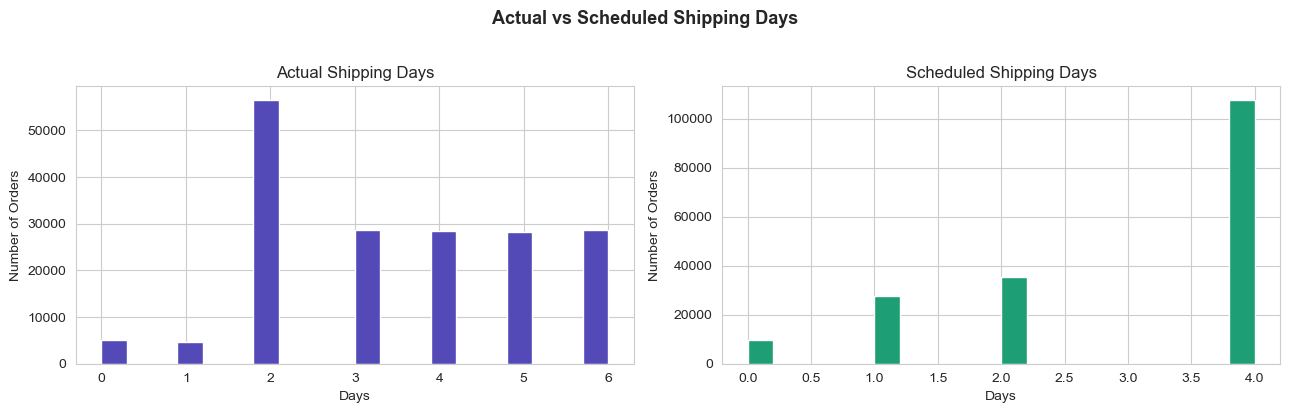

In [20]:
# Chart 2: Actual vs Scheduled shipping days 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# plt.subplots(1, 2) creates a figure with 1 row and 2 columns of charts side by side

# Left chart: histogram of actual shipping days
# bins=20 splits the data range into 20 equal buckets
df['Days for shipping (real)'].hist(
    bins=20, color='#534AB7', edgecolor='white', ax=axes[0]
)
axes[0].set_title('Actual Shipping Days', fontsize=12)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Orders')

# Right chart: histogram of scheduled shipping days
df['Days for shipment (scheduled)'].hist(
    bins=20, color='#1D9E75', edgecolor='white', ax=axes[1]
)
axes[1].set_title('Scheduled Shipping Days', fontsize=12)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Number of Orders')

plt.suptitle('Actual vs Scheduled Shipping Days', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_actual_vs_scheduled_shipping_days.png', bbox_inches='tight')
plt.show()

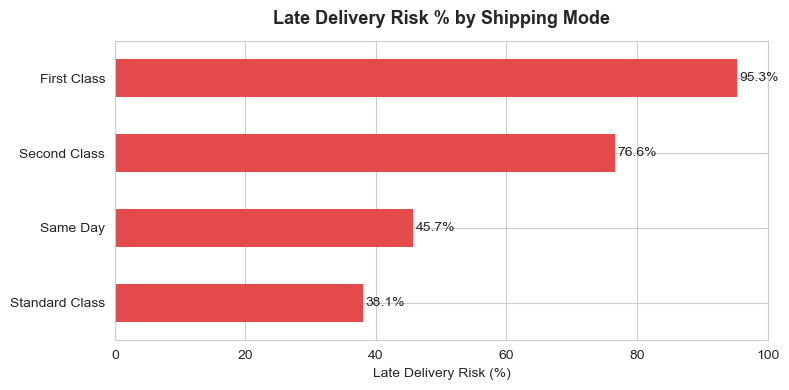

In [21]:
# Chart 3: Late delivery risk by shipping mode 
# groupby() groups all rows by Shipping Mode
# Then we take the mean of Late_delivery_risk within each group
# Mean of a 0/1 column = proportion of 1s = late delivery rate for that mode
late_by_mode = (
    df.groupby('Shipping Mode')['Late_delivery_risk']
    .mean() * 100   # Convert proportion to percentage
).sort_values(ascending=True)  # Sort so worst mode appears at bottom

fig, ax = plt.subplots(figsize=(8, 4))
late_by_mode.plot(kind='barh', color='#E24B4A', edgecolor='none', ax=ax)

ax.set_title('Late Delivery Risk % by Shipping Mode', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Late Delivery Risk (%)')
ax.set_ylabel('')

# Add % labels to the right of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
        va='center', fontsize=10
    )

plt.tight_layout()
plt.savefig('03_late_delivery_risk_by_shipping_mode.png', bbox_inches='tight')
plt.show()

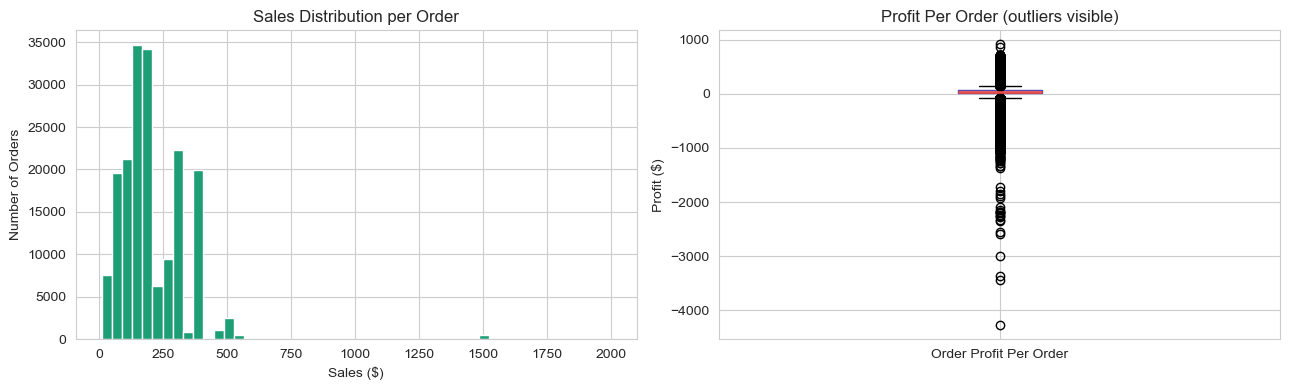

In [22]:
# Chart 4: Sales and Profit distributions 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of order sales values
# bins=50 creates fine-grained buckets to show the shape of the distribution clearly
df['Sales'].hist(bins=50, color='#1D9E75', edgecolor='white', ax=axes[0])
axes[0].set_title('Sales Distribution per Order', fontsize=12)
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Number of Orders')

# Right: box plot of profit per order
# A box plot shows: whisker=min/max, box=25th-75th percentile, line=median, dots=outliers
df.boxplot(
    column='Order Profit Per Order',
    ax=axes[1],
    boxprops=dict(color='#534AB7'),       # Box outline colour
    medianprops=dict(color='#E24B4A', linewidth=2)  # Median line colour
)
axes[1].set_title('Profit Per Order (outliers visible)', fontsize=12)
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig('04_sales_and_profit_distribution.png', bbox_inches='tight')
plt.show()

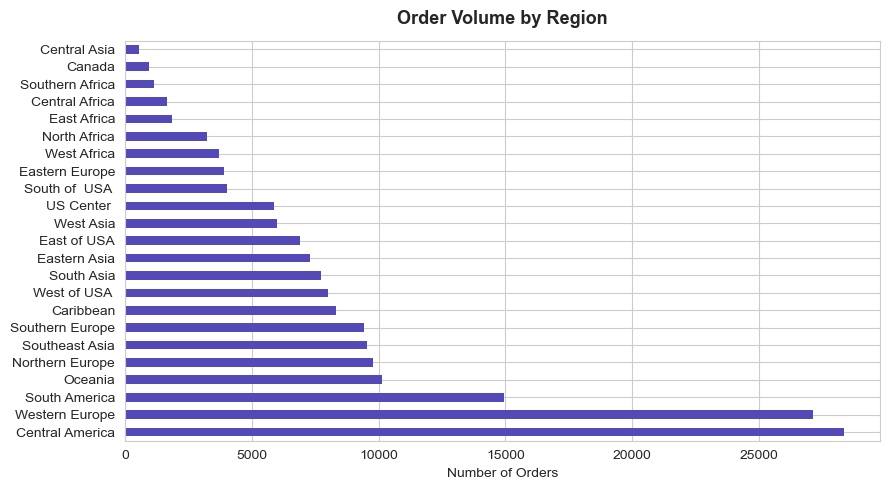

In [23]:
# Chart 5: Orders by Region 
fig, ax = plt.subplots(figsize=(9, 5))

df['Order Region'].value_counts().plot(
    kind='barh',
    color='#534AB7',
    edgecolor='none',
    ax=ax
)

ax.set_title('Order Volume by Region', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Orders')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('05_orders_by_region.png', bbox_inches='tight')
plt.show()

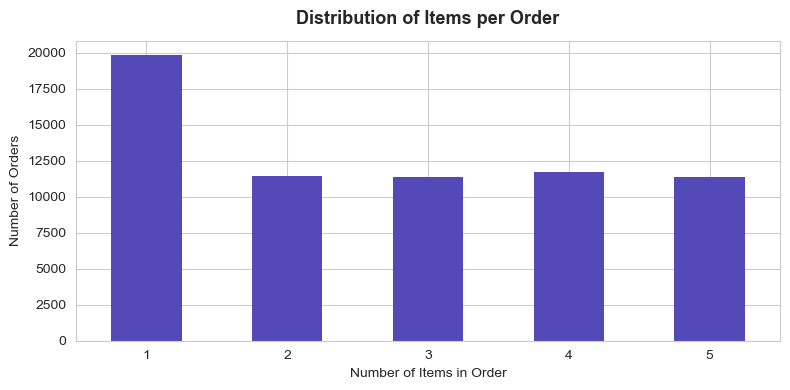


⚠️  KEY INSIGHT FOR POWER BI:
   Because one Order Id can appear multiple times (up to 5 times),
   all order-level KPIs in Power BI must use DISTINCTCOUNT(Order Id)
   not COUNTROWS(). Using COUNTROWS would overcount by ~2.75x.



In [24]:
# Order-item structure analysis 
# Definition: since this dataset is at order-item level, understanding
# how many items per order exist is critical for correct aggregation later
fig, ax = plt.subplots(figsize=(8, 4))
items_per_order.value_counts().sort_index().plot(
    kind='bar', color='#534AB7', edgecolor='none', ax=ax
)
ax.set_title('Distribution of Items per Order', fontsize=13,
             fontweight='bold', pad=12)
ax.set_xlabel('Number of Items in Order')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('06_distribution_item_per_order.png', bbox_inches='tight')
plt.show()

print("""
⚠️  KEY INSIGHT FOR POWER BI:
   Because one Order Id can appear multiple times (up to 5 times),
   all order-level KPIs in Power BI must use DISTINCTCOUNT(Order Id)
   not COUNTROWS(). Using COUNTROWS would overcount by ~2.75x.
""")

# Correlation Check

Correlation measures how closely two numeric columns move together, expressed as a number between **-1 and +1**:

| Correlation value | Meaning |
|---|---|
| Close to **+1** | When one goes up, the other goes up — strong positive relationship |
| Close to **-1** | When one goes up, the other goes down — strong negative relationship |
| Close to **0** | No meaningful relationship between the two columns |

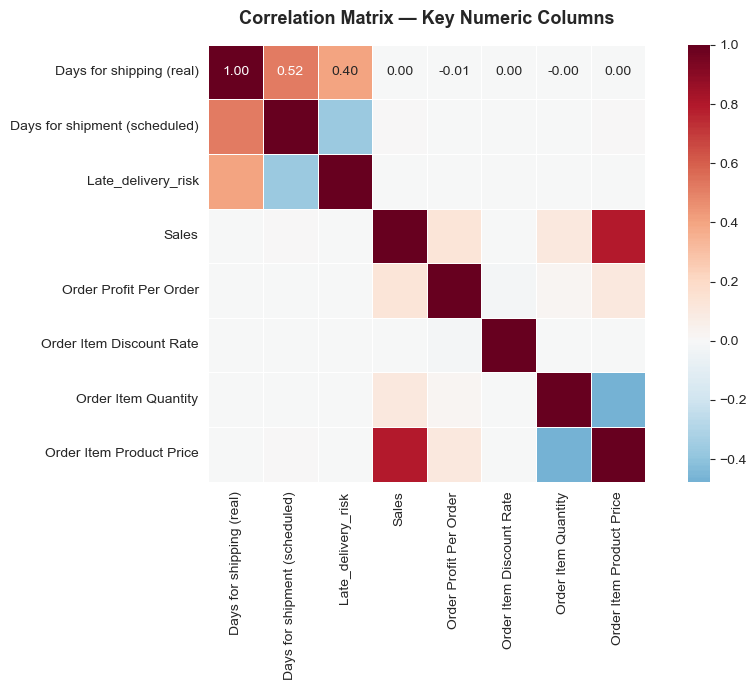

In [25]:
# Select relevant numeric columns for correlation 
# Skip ID columns (order ID, customer ID) — correlating IDs is meaningless
corr_cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk',
    'Sales',
    'Order Profit Per Order',
    'Order Item Discount Rate',
    'Order Item Quantity',
    'Order Item Product Price'
]

# Keep only columns that actually exist in this version of the dataset
corr_cols = [c for c in corr_cols if c in df.columns]

# .corr() computes pairwise Pearson correlation between every pair of selected columns
# The result is a square matrix: rows and columns are the same columns
corr_matrix = df[corr_cols].corr()

# Draw a heatmap of the correlation matrix 
# A heatmap colours each cell by its correlation value
# Dark red = strong positive | Dark blue = strong negative | White = no correlation
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,       # Print the correlation number inside each cell
    fmt='.2f',        # Round numbers to 2 decimal places
    cmap='RdBu_r',    # Red-Blue colormap reversed (red=positive, blue=negative)
    center=0,         # White = 0 (no correlation)
    square=True,      # Make each cell square, not rectangular
    linewidths=0.5,   # Thin white lines between cells
    ax=ax
)

ax.set_title('Correlation Matrix — Key Numeric Columns', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('06_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Summary

In [26]:
# Auto-generate findings summary 
total_rows      = df.shape[0]
total_cols      = df.shape[1]
unique_orders   = df['Order Id'].nunique()
items_per_order = total_rows / unique_orders

print("=" * 65)
print("  PHASE 1 — EXPLORATION FINDINGS SUMMARY")
print("=" * 65)
print(f"""
   DATASET STRUCTURE
   Total rows (order items) : {total_rows:,}
   Unique Order IDs         : {unique_orders:,}
   Avg items per order      : {items_per_order:.2f}
   Columns                  : {total_cols}
   Memory                   : {df.memory_usage(deep=True).sum()/1024**2:.1f} MB

   ⚠️  IMPORTANT: This dataset is structured at ORDER-ITEM level.
   One order can contain multiple products, creating multiple rows
   per Order Id. All aggregations must account for this.

   COLUMN TYPE BREAKDOWN
   Numeric columns : {len(df.select_dtypes(include='number').columns)}
   Text columns    : {len(df.select_dtypes(include='object').columns)}

⚠️  DATA QUALITY ISSUES TO FIX IN PHASE 2
   Total null cells   : {df.isnull().sum().sum():,}
   Columns with nulls : {(df.isnull().sum() > 0).sum()}
   Duplicate rows     : {df.duplicated().sum():,}
   Date columns stored as text → need datetime conversion

   KEY BUSINESS METRICS PREVIEW
   Unique orders              : {unique_orders:,}
   Late delivery risk rate    : {df['Late_delivery_risk'].mean()*100:.1f}%
   Avg actual shipping days   : {df['Days for shipping (real)'].mean():.1f} days
   Avg scheduled ship days    : {df['Days for shipment (scheduled)'].mean():.1f} days
   Avg profit per order item  : ${df['Order Profit Per Order'].mean():.2f}
   Unique regions             : {df['Order Region'].nunique()}
   Unique shipping modes      : {df['Shipping Mode'].nunique()}

✅ ACTIONS FOR PHASE 2
   1. Convert date columns from text to datetime
   2. Drop Order Zipcode (86.2% missing)
   3. Drop 3 rows where Customer Zipcode is null
   4. Engineer: actual_delay_days, is_late, profit_margin_pct,
                supplier_segment, order_year/month/quarter
   5. Build star schema and export clean CSVs
   6. NOTE: All order-level KPIs must use DISTINCTCOUNT in Power BI
""")
print("=" * 65)
print("  Next: 02_data_cleaning_feature_engineering.ipynb")
print("=" * 65)

  PHASE 1 — EXPLORATION FINDINGS SUMMARY

   DATASET STRUCTURE
   Total rows (order items) : 180,519
   Unique Order IDs         : 65,752
   Avg items per order      : 2.75
   Columns                  : 53
   Memory                   : 333.7 MB

   ⚠️  IMPORTANT: This dataset is structured at ORDER-ITEM level.
   One order can contain multiple products, creating multiple rows
   per Order Id. All aggregations must account for this.

   COLUMN TYPE BREAKDOWN
   Numeric columns : 29
   Text columns    : 24

⚠️  DATA QUALITY ISSUES TO FIX IN PHASE 2
   Total null cells   : 336,209
   Columns with nulls : 4
   Duplicate rows     : 0
   Date columns stored as text → need datetime conversion

   KEY BUSINESS METRICS PREVIEW
   Unique orders              : 65,752
   Late delivery risk rate    : 54.8%
   Avg actual shipping days   : 3.5 days
   Avg scheduled ship days    : 2.9 days
   Avg profit per order item  : $21.97
   Unique regions             : 23
   Unique shipping modes      : 4

✅ AC

## ✅ Phase 1 Complete — Key Findings

### Dataset structure
| Property | Value | Implication |
|---|---|---|
| Total rows | 180,516 | Each row = one order item |
| Unique orders | 65,749 | True order count for KPIs |
| Avg items per order | ~2.75 | COUNTROWS inflates by 2.75x |
| Columns | 53 | Mix of numeric and text |

### Data quality issues found
| Issue | Severity | Action in Phase 2 |
|---|---|---|
| Product Description — 100% missing | High | Drop column |
| Order Zipcode — 86.2% missing | High | Drop column |
| Customer Zipcode — 3 missing | Low | Drop those 3 rows |
| Customer Lname — 8 missing | Low | Drop column (personal data) |
| Date columns stored as text | High | Convert to datetime |
| Duplicate rows | None | No action needed |

### Key business signals
| Metric | Value | Significance |
|---|---|---|
| Late delivery risk rate | 54.8% | Over half of orders at risk |
| Avg actual shipping days | 3.5 | Consistently exceeds schedule |
| Avg scheduled shipping days | 2.9 | Underestimated by 0.6 days |
| Avg profit per item | $21.97 | Thin margins across the board |
| Unique regions | 23 | Strong geographic diversity |
| Shipping modes | 4 | Standard, Second, First, Same Day |

### Critical note for all downstream phases
> **All order-level KPIs must be computed using `DISTINCTCOUNT(Order Id)`
> in Power BI and `df.groupby('Order Id')` in Python — never raw
> COUNTROWS or len(df). Failure to account for the order-item structure
> will inflate all counts by approximately 2.75x.**

---
**Next:** `02_data_cleaning_feature_engineering.ipynb`